In [ ]:
import os
import zipfile
from google.colab import files

OUTDIR = "/content/figures_pdf"
os.makedirs(OUTDIR, exist_ok=True)

<>:100: SyntaxWarning: invalid escape sequence '\i'
<>:100: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_1696/3022913081.py:100: SyntaxWarning: invalid escape sequence '\i'
  E[ \int c_t^gamma/gamma dt + k_terminal X_T ]


Running 1D benchmark with recurrent student distilled from PGDPO projection ...

########################################################################################################################
[Experiment Start] T=1.0, N=20, delta=0.4
########################################################################################################################

1D PGDPO Projection -> Recurrent Student Distillation Experiment
device                         = cuda:0
projection rollout batch       = 128
student init                   = warm-up policy copy
student train objective        = supervised fit to projected controls
stage1 train sec               = 74.805915
student train sec              = 68.536330
--------------------------------------------------------------------------------------------------------------
Method               |  RMSE vs benchmark |   MAE vs benchmark
-------------------------------------------------------------------------------------------------------------

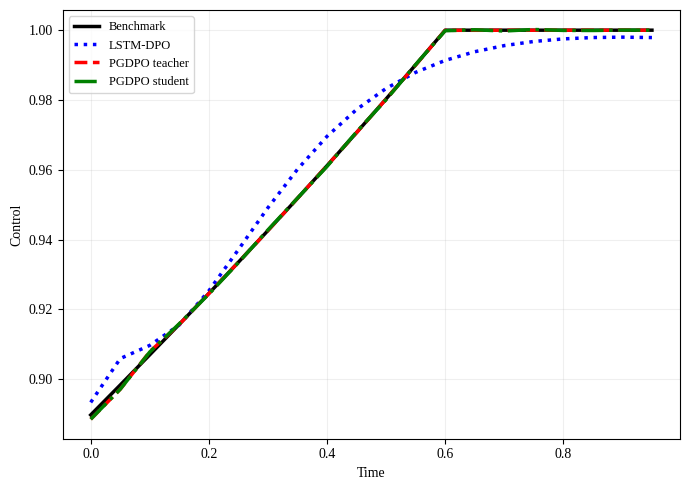

[Saved] /content/figures_pdf/T1_teacher_vs_student.pdf


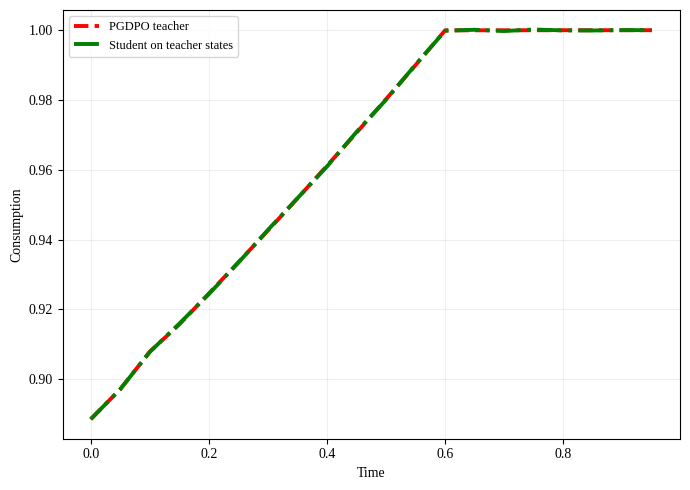

[Saved] /content/figures_pdf/T1_runtime_comparison.pdf


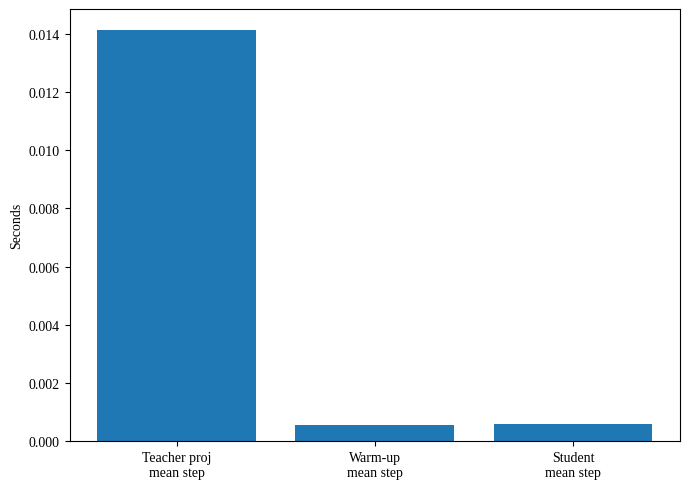

[Saved] /content/figures_pdf/T1_accuracy_comparison.pdf


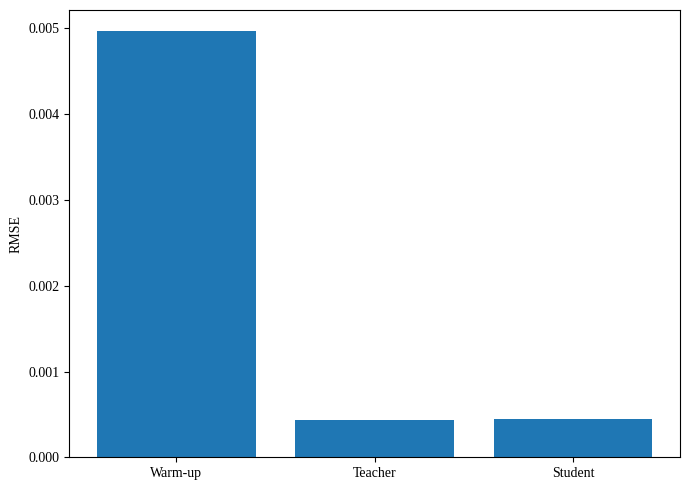


########################################################################################################################
[Experiment Start] T=30.0, N=600, delta=0.4
########################################################################################################################

1D PGDPO Projection -> Recurrent Student Distillation Experiment
device                         = cuda:0
projection rollout batch       = 128
student init                   = warm-up policy copy
student train objective        = supervised fit to projected controls
stage1 train sec               = 2242.303132
student train sec              = 1966.319029
--------------------------------------------------------------------------------------------------------------
Method               |  RMSE vs benchmark |   MAE vs benchmark
--------------------------------------------------------------------------------------------------------------
Warm-up LSTM-DPO     |         0.02437127 |         0.01400643
Teacher P

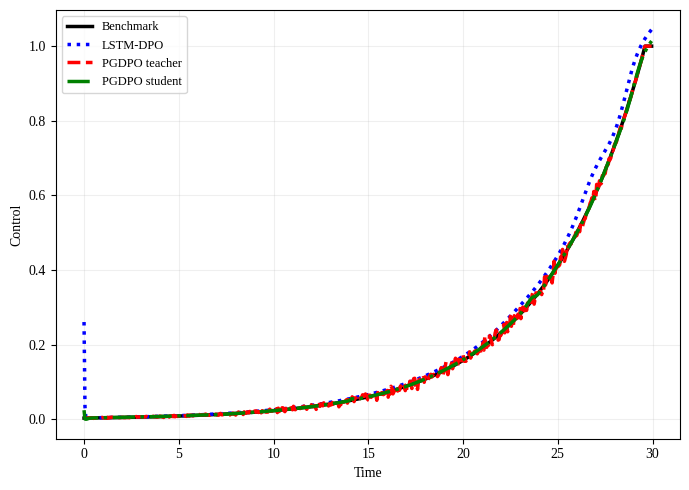

[Saved] /content/figures_pdf/T30_teacher_vs_student.pdf


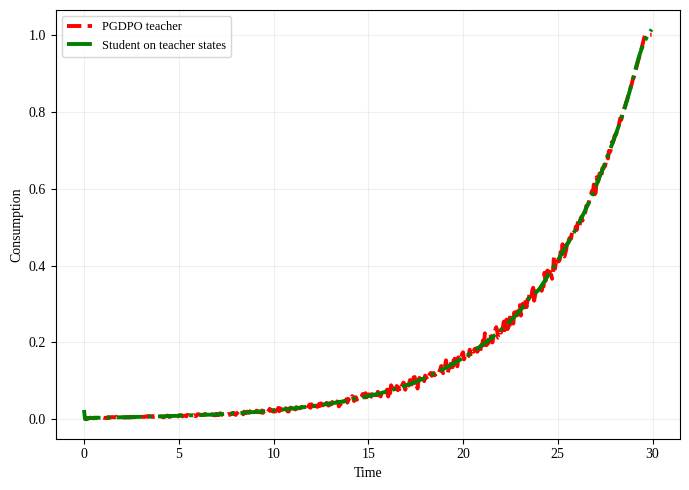

[Saved] /content/figures_pdf/T30_runtime_comparison.pdf


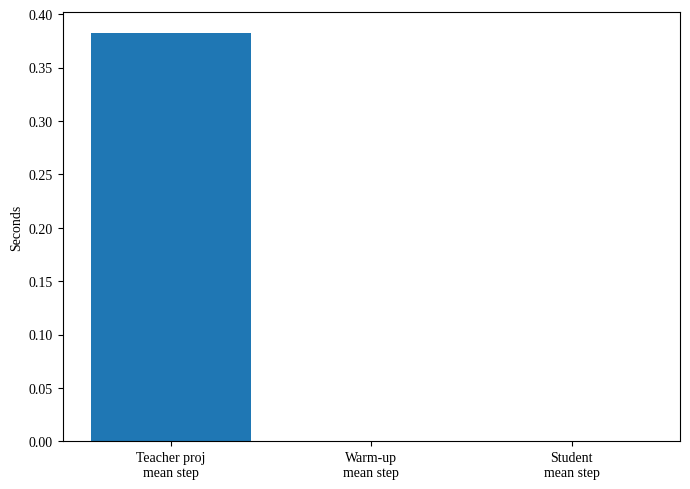

[Saved] /content/figures_pdf/T30_accuracy_comparison.pdf


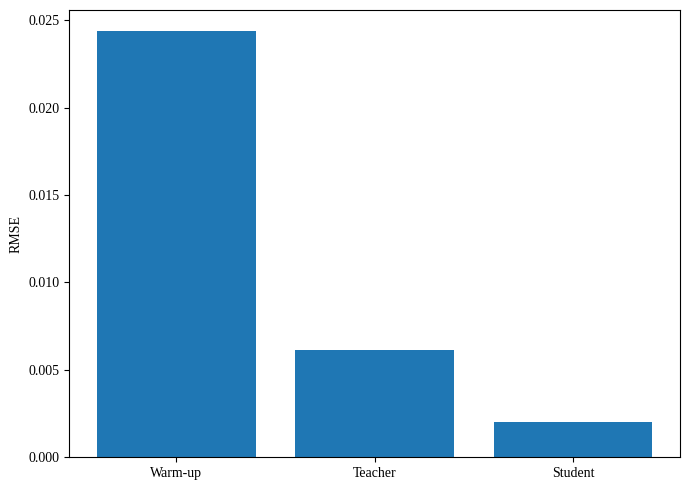


########################################################################################################################
Compact numeric comparison: T=1 vs T=30
########################################################################################################################
     T |   Warm-up RMSE |   Teacher RMSE |   Student RMSE |    Warm-up MAE |    Teacher MAE |    Student MAE | Proj mean step | Student mean step |      Speedup
----------------------------------------------------------------------------------------------------------------------------------------------------------------
   1.0 |     0.00496650 |     0.00043448 |     0.00044718 |     0.00423180 |     0.00018520 |     0.00027416 |     0.01414522 |        0.00057658 |      24.5329
  30.0 |     0.02437127 |     0.00615459 |     0.00199462 |     0.01400643 |     0.00400677 |     0.00092823 |     0.38276557 |        0.00053793 |     711.5473
[ZIP saved] /content/figures_Distillation_pdf.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import time
import copy
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

plt.rcParams.update({
    "pdf.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Liberation Serif", "FreeSerif", "serif"],
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "mathtext.fontset": "stix",
})

# =============================================================================
# 0. Global config
# =============================================================================
torch.set_default_dtype(torch.float64)

CFG = {
    # reproducibility / device
    "seed": 42,
    "device": "cuda:0" if torch.cuda.is_available() else "cpu",

    # 1D benchmark-1 parameters
    "alpha": 0.10,
    "beta": 0.20,
    "gamma": 0.5,
    "k_terminal": 1.0,
    "T": 1.0,
    "N": 20,
    "delta": 0.4,
    "X0": 1.0,

    # stage-1 warm-up
    "hidden": 128,
    "lr": 3e-4,
    "train_paths": 256,
    "n_iters": 2000,

    # stage-2 projection: fixed scalar batch size
    "proj_rollouts": 128,

    # recurrent student distillation
    "student_lr": 1e-3,
    "student_epochs": 3000,
    "student_weight_decay": 1e-6,
    "student_anchor_lambda": 0.0,  # optional regularization toward warm-up outputs

    # plotting / misc
    "make_plot": True,
}

DEVICE = torch.device(CFG["device"])


# =============================================================================
# 1. Utilities
# =============================================================================
def set_seed(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _safe_power_from_costate(p, gamma):
    p_clamped = torch.clamp(p, min=1e-12)
    return p_clamped.pow(1.0 / (gamma - 1.0))


def rmse(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    return float(np.sqrt(np.mean((a - b) ** 2)))


def mae(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    return float(np.mean(np.abs(a - b)))


# =============================================================================
# 2. Physics (1D only)
# =============================================================================
class Physics1D:
    """
    1D delayed benchmark:
        dX_t = (alpha X_{t-delta} - c_t) dt + beta X_{t-delta} dW_t

    objective:
        E[ \int c_t^gamma/gamma dt + k_terminal X_T ]
    """

    def __init__(self, cfg):
        self.gamma = float(cfg["gamma"])
        self.h = float(cfg["T"]) / int(cfg["N"])
        self.delay_steps = int(round(float(cfg["delta"]) / self.h))

        self.alpha = torch.tensor(float(cfg["alpha"]), device=DEVICE)
        self.beta = torch.tensor(float(cfg["beta"]), device=DEVICE)
        self.k_term = torch.tensor(float(cfg["k_terminal"]), device=DEVICE)
        self.x0 = torch.tensor(float(cfg["X0"]), device=DEVICE)

    def step(self, x_now, x_lag, u, dW):
        drift = self.alpha * x_lag - u
        diff = self.beta * x_lag
        return x_now + drift * self.h + diff * dW

    def utility(self, u):
        return u.pow(self.gamma) / self.gamma

    def terminal_reward(self, x_final):
        return self.k_term * x_final

    def init_history(self, batch_size: int):
        x0_batch = self.x0.view(1, 1).repeat(batch_size, 1)
        return [x0_batch.clone() for _ in range(self.delay_steps + 1)]


# =============================================================================
# 3. Recurrent policy network (used for both warm-up and student)
# =============================================================================
class BaseLSTM(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, inp, hidden):
        out, hidden_new = self.lstm(inp.unsqueeze(1), hidden)
        return self.fc(out[:, -1, :]), hidden_new


class PolicyNet(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.base = BaseLSTM(input_dim=2, output_dim=1, hidden_dim=hidden_dim)

    def forward(self, t, x, hidden):
        inp = torch.cat([t.unsqueeze(-1), x], dim=-1)
        raw, hidden_new = self.base(inp, hidden)
        c = torch.nn.functional.softplus(raw) + 1e-8
        return c, hidden_new


# =============================================================================
# 4. Analytic benchmark
# =============================================================================
def solve_analytic_1d(phy: Physics1D, cfg):
    """
    Discrete 1D analytic benchmark:
        p[n] = p[n+1] + alpha * h * p[n+1+delay]
        c[n] = p[n]^(1/(gamma-1))
    """
    N = int(cfg["N"])
    delay = phy.delay_steps
    h = phy.h

    p = np.zeros(N + 1, dtype=np.float64)
    p[N - delay:] = float(phy.k_term.detach().cpu().item())

    alpha = float(phy.alpha.detach().cpu().item())

    for i in range(N - delay - 1, -1, -1):
        p[i] = p[i + 1] + alpha * h * p[i + 1 + delay]

    c_star = np.maximum(p, 1e-12) ** (1.0 / (phy.gamma - 1.0))
    return c_star, p


# =============================================================================
# 5. Stage-1 warm-up
# =============================================================================
def train_lstm_dpo(policy: nn.Module, phy: Physics1D, cfg, verbose=False):
    opt = optim.Adam(policy.parameters(), lr=cfg["lr"])

    B = int(cfg["train_paths"])
    N = int(cfg["N"])

    for it in range(1, cfg["n_iters"] + 1):
        opt.zero_grad()

        dW = torch.randn(B, N, 1, device=DEVICE) * math.sqrt(phy.h)

        X = torch.zeros(B, N + phy.delay_steps + 1, 1, device=DEVICE)
        X[:, :phy.delay_steps + 1, :] = phy.x0.view(1, 1, 1)

        hidden = None
        running_utility = torch.zeros(B, device=DEVICE)

        for n in range(N):
            k = phy.delay_steps + n
            t_val = torch.full((B,), n * phy.h, device=DEVICE)

            x_now = X[:, k, :]
            x_lag = X[:, n, :]

            c_n, hidden = policy(t_val, x_now, hidden)
            x_next = phy.step(x_now, x_lag, c_n, dW[:, n, :])

            X[:, k + 1, :] = x_next
            running_utility = running_utility + phy.utility(c_n).squeeze(-1) * phy.h

        terminal_reward = phy.terminal_reward(X[:, -1, :]).squeeze(-1)
        loss = -(running_utility + terminal_reward).mean()

        loss.backward()
        opt.step()

        if verbose and (it % 500 == 0 or it == 1 or it == cfg["n_iters"]):
            print(f"[Stage1] iter={it:5d} | loss={loss.item():.8f}")

    return policy


def rollout_policy_deterministic(policy: nn.Module, phy: Physics1D, cfg, measure_time=False):
    c_path = []
    x_path = []
    step_times = []

    with torch.no_grad():
        hidden = None
        X = phy.init_history(1)

        for i in range(cfg["N"]):
            t0 = time.perf_counter() if measure_time else None

            k = phy.delay_steps + i
            t_i = torch.tensor([i * phy.h], device=DEVICE)
            x_now = X[k]
            x_lag = X[i]

            c_i, hidden = policy(t_i, x_now, hidden)
            c_path.append(float(c_i.item()))
            x_path.append(float(x_now.item()))

            x_next = phy.step(x_now, x_lag, c_i, torch.zeros_like(x_now))
            X.append(x_next)

            if measure_time:
                step_times.append(time.perf_counter() - t0)

    if measure_time:
        return (
            np.array(c_path),
            np.array(x_path),
            float(np.mean(step_times)),
            float(np.max(step_times)),
            step_times,
        )
    return np.array(c_path), np.array(x_path)


# =============================================================================
# 6. Stage-2 projection teacher generation
# =============================================================================
def sample_antithetic_dW(batch_size: int, h: float, device=DEVICE):
    half = batch_size // 2
    scale = math.sqrt(h)

    eps_half = torch.randn(half, 1, device=device) * scale
    dW = torch.cat([eps_half, -eps_half], dim=0)

    if batch_size % 2 == 1:
        extra = torch.randn(1, 1, device=device) * scale
        dW = torch.cat([dW, extra], dim=0)

    return dW


def compute_pgdpo_teacher_dataset(policy: nn.Module, phy: Physics1D, cfg):
    """
    Returns teacher sequence collected from deterministic projected rollout.
    The teacher controls are the projected controls c_proj[i].
    The student will later imitate this control sequence using the same recurrent architecture.
    """
    N = int(cfg["N"])
    M = int(cfg["proj_rollouts"])

    c_proj = []
    p_proj = []
    state_list = []
    time_list = []
    proj_times = []

    real_hist = [phy.x0.view(1, 1).clone() for _ in range(phy.delay_steps + 1)]
    real_hidden_hist = [None]

    def _clone_hidden(hidden):
        if hidden is None:
            return None
        h, c = hidden
        return (h.detach().clone(), c.detach().clone())

    def _expand_hidden(hidden, batch_size: int):
        if hidden is None:
            return None
        h, c = hidden
        h = h.expand(-1, batch_size, -1).contiguous()
        c = c.expand(-1, batch_size, -1).contiguous()
        return (h, c)

    hidden_real = None

    for i in range(N):
        t0 = time.perf_counter()

        x_anchor = real_hist[-1].detach().clone().requires_grad_(True)
        state_list.append(float(x_anchor.item()))
        time_list.append(i * phy.h)

        hidden_prefix = real_hidden_hist[i]
        hidden_inner = _expand_hidden(hidden_prefix, M)

        past_hist = torch.stack(real_hist[:-1], dim=0).detach()
        past_hist = past_hist[-phy.delay_steps:]
        past_hist = past_hist.expand(-1, M, -1)

        curr_state = x_anchor.expand(M, -1)
        inner_X = [past_hist[k] for k in range(phy.delay_steps)] + [curr_state]

        J_future = torch.zeros(M, device=DEVICE)

        for step in range(N - i):
            abs_step = i + step
            k_idx = phy.delay_steps + step
            t_val = torch.full((M,), abs_step * phy.h, device=DEVICE)

            x_now = inner_X[k_idx]
            x_lag = inner_X[step]

            c_val, hidden_inner = policy(t_val, x_now, hidden_inner)

            dW = sample_antithetic_dW(M, phy.h, device=DEVICE)
            x_next = phy.step(x_now, x_lag, c_val, dW)

            inner_X.append(x_next)
            J_future = J_future + phy.utility(c_val).squeeze(-1) * phy.h

        J_total = J_future + phy.terminal_reward(inner_X[-1]).squeeze(-1)

        grad = torch.autograd.grad(J_total.sum(), x_anchor)[0] / M
        p_t = grad.squeeze(0)
        c_star = _safe_power_from_costate(p_t, phy.gamma)

        c_proj.append(float(c_star.item()))
        p_proj.append(float(p_t.item()))

        t_real = torch.tensor([i * phy.h], device=DEVICE)
        with torch.no_grad():
            _, hidden_real = policy(t_real, real_hist[-1], hidden_real)

        x_next_real = phy.step(
            real_hist[-1],
            real_hist[-(phy.delay_steps + 1)],
            c_star.view(1, 1),
            torch.zeros_like(real_hist[-1]),
        )
        real_hist.append(x_next_real.detach())
        real_hidden_hist.append(_clone_hidden(hidden_real))

        proj_times.append(time.perf_counter() - t0)

    return {
        "teacher_control": np.array(c_proj),
        "teacher_costate": np.array(p_proj),
        "teacher_state": np.array(state_list),
        "teacher_time": np.array(time_list),
        "proj_time_mean": float(np.mean(proj_times)),
        "proj_time_max": float(np.max(proj_times)),
        "proj_times": proj_times,
    }


# =============================================================================
# 7. Recurrent student distillation
# =============================================================================
def train_recurrent_student_from_projection(warmup_policy, phy: Physics1D, cfg, teacher_data, verbose=False):
    """
    Student is an exact copy of the warm-up recurrent policy.
    It is then fine-tuned by supervised learning on the projection teacher sequence.

    Important:
      - the student updates its OWN hidden state sequentially,
      - inputs are the teacher rollout states/time sequence,
      - target is the projected control sequence.
    """
    student = copy.deepcopy(warmup_policy).to(DEVICE)
    student.train()

    opt = optim.Adam(
        student.parameters(),
        lr=cfg["student_lr"],

    )
    loss_fn = nn.MSELoss()

    t_seq = torch.tensor(teacher_data["teacher_time"], device=DEVICE).view(-1)
    x_seq = torch.tensor(teacher_data["teacher_state"], device=DEVICE).view(-1, 1)
    y_seq = torch.tensor(teacher_data["teacher_control"], device=DEVICE).view(-1, 1)

    with torch.no_grad():
        warmup_outputs = []
        hidden_w = None
        for i in range(len(t_seq)):
            pred_w, hidden_w = warmup_policy(t_seq[i:i+1], x_seq[i:i+1], hidden_w)
            warmup_outputs.append(pred_w)
        warmup_outputs = torch.cat(warmup_outputs, dim=0)

    best_state = copy.deepcopy(student.state_dict())
    best_loss = float("inf")

    for epoch in range(1, cfg["student_epochs"] + 1):
        opt.zero_grad()
        hidden_s = None
        preds = []

        for i in range(len(t_seq)):
            pred_s, hidden_s = student(t_seq[i:i+1], x_seq[i:i+1], hidden_s)
            preds.append(pred_s)

        preds = torch.cat(preds, dim=0)
        loss_sup = loss_fn(preds, y_seq)

        if cfg["student_anchor_lambda"] > 0.0:
            loss_anchor = loss_fn(preds, warmup_outputs)
            loss = loss_sup + cfg["student_anchor_lambda"] * loss_anchor
        else:
            loss_anchor = torch.tensor(0.0, device=DEVICE)
            loss = loss_sup

        loss.backward()
        opt.step()

        loss_val = float(loss.item())
        if loss_val < best_loss:
            best_loss = loss_val
            best_state = copy.deepcopy(student.state_dict())

        if verbose and (epoch % 500 == 0 or epoch == 1 or epoch == cfg["student_epochs"]):
            print(
                f"[Student] epoch={epoch:5d} | total_loss={loss.item():.10f} | "
                f"sup_mse={loss_sup.item():.10f} | anchor_mse={loss_anchor.item():.10f}"
            )

    student.load_state_dict(best_state)
    student.eval()
    return student, best_loss


# =============================================================================
# 8. Main experiment
# =============================================================================
def run_1d_projection_distillation_experiment(cfg, verbose=False):
    set_seed(cfg["seed"])
    phy = Physics1D(cfg)

    # analytic benchmark
    c_analytic, p_analytic = solve_analytic_1d(phy, cfg)
    benchmark = c_analytic[:-1]

    # stage 1 warm-up
    stage1_t0 = time.perf_counter()
    warmup_policy = PolicyNet(hidden_dim=cfg["hidden"]).to(DEVICE)
    warmup_policy = train_lstm_dpo(warmup_policy, phy, cfg, verbose=verbose)
    stage1_train_sec = time.perf_counter() - stage1_t0

    c_stage1, x_stage1, warmup_mean_step_time, warmup_max_step_time, warmup_step_times = rollout_policy_deterministic(
        warmup_policy, phy, cfg, measure_time=True
    )

    # teacher projection sequence
    set_seed(cfg["seed"] + 1000 + int(cfg["proj_rollouts"]))
    teacher_data = compute_pgdpo_teacher_dataset(warmup_policy, phy, cfg)

    # student recurrent distillation
    student_t0 = time.perf_counter()
    student_policy, student_best_loss = train_recurrent_student_from_projection(
        warmup_policy=warmup_policy,
        phy=phy,
        cfg=cfg,
        teacher_data=teacher_data,
        verbose=verbose,
    )
    student_train_sec = time.perf_counter() - student_t0

    c_student, x_student, student_mean_step_time, student_max_step_time, student_step_times = rollout_policy_deterministic(
        student_policy, phy, cfg, measure_time=True
    )

    # teacher fit on teacher states (diagnostic)
    with torch.no_grad():
        hidden_diag = None
        diag_preds = []
        t_seq = torch.tensor(teacher_data["teacher_time"], device=DEVICE).view(-1)
        x_seq = torch.tensor(teacher_data["teacher_state"], device=DEVICE).view(-1, 1)
        for i in range(len(t_seq)):
            pred, hidden_diag = student_policy(t_seq[i:i+1], x_seq[i:i+1], hidden_diag)
            diag_preds.append(float(pred.item()))
    diag_preds = np.array(diag_preds)

    # metrics vs analytic benchmark
    stage1_metrics = {
        "RMSE": rmse(c_stage1, benchmark),
        "MAE": mae(c_stage1, benchmark),
    }
    teacher_metrics = {
        "RMSE": rmse(teacher_data["teacher_control"], benchmark),
        "MAE": mae(teacher_data["teacher_control"], benchmark),
    }
    student_metrics = {
        "RMSE": rmse(c_student, benchmark),
        "MAE": mae(c_student, benchmark),
        "teacher_fit_RMSE": rmse(diag_preds, teacher_data["teacher_control"]),
        "teacher_fit_MAE": mae(diag_preds, teacher_data["teacher_control"]),
    }

    results = {
        "benchmark": benchmark,
        "analytic_costate": p_analytic[:-1],
        "warmup_control": c_stage1,
        "warmup_state": x_stage1,
        "teacher_control": teacher_data["teacher_control"],
        "teacher_costate": teacher_data["teacher_costate"],
        "teacher_state": teacher_data["teacher_state"],
        "teacher_time": teacher_data["teacher_time"],
        "student_control": c_student,
        "student_state": x_student,
        "student_diag_on_teacher_states": diag_preds,
        "stage1_metrics": stage1_metrics,
        "teacher_metrics": teacher_metrics,
        "student_metrics": student_metrics,
        "stage1_train_sec": stage1_train_sec,
        "student_train_sec": student_train_sec,
        "student_best_loss": student_best_loss,
        "proj_time_mean": teacher_data["proj_time_mean"],
        "proj_time_max": teacher_data["proj_time_max"],
        "proj_times": teacher_data["proj_times"],
        "warmup_mean_step_time": warmup_mean_step_time,
        "warmup_max_step_time": warmup_max_step_time,
        "warmup_step_times": warmup_step_times,
        "student_mean_step_time": student_mean_step_time,
        "student_max_step_time": student_max_step_time,
        "student_step_times": student_step_times,
        "speedup_student_vs_projection": teacher_data["proj_time_mean"] / max(student_mean_step_time, 1e-12),
        "speedup_warmup_vs_projection": teacher_data["proj_time_mean"] / max(warmup_mean_step_time, 1e-12),
    }
    return results


# =============================================================================
# 9. Plotting / reporting
# =============================================================================
def print_summary(results, cfg):
    print("\n" + "=" * 110)
    print("1D PGDPO Projection -> Recurrent Student Distillation Experiment")
    print("=" * 110)
    print(f"device                         = {cfg['device']}")
    print(f"projection rollout batch       = {cfg['proj_rollouts']}")
    print(f"student init                   = warm-up policy copy")
    print(f"student train objective        = supervised fit to projected controls")
    print(f"stage1 train sec               = {results['stage1_train_sec']:.6f}")
    print(f"student train sec              = {results['student_train_sec']:.6f}")
    print("-" * 110)
    print(f"{'Method':<20} | {'RMSE vs benchmark':>18} | {'MAE vs benchmark':>18}")
    print("-" * 110)
    print(f"{'Warm-up LSTM-DPO':<20} | {results['stage1_metrics']['RMSE']:18.8f} | {results['stage1_metrics']['MAE']:18.8f}")
    print(f"{'Teacher PGDPO':<20} | {results['teacher_metrics']['RMSE']:18.8f} | {results['teacher_metrics']['MAE']:18.8f}")
    print(f"{'Student recurrent':<20} | {results['student_metrics']['RMSE']:18.8f} | {results['student_metrics']['MAE']:18.8f}")
    print("-" * 110)
    print(f"projection mean step time      = {results['proj_time_mean']:.8f} sec")
    print(f"projection max  step time      = {results['proj_time_max']:.8f} sec")
    print(f"warm-up  mean step time        = {results['warmup_mean_step_time']:.8f} sec")
    print(f"warm-up  max  step time        = {results['warmup_max_step_time']:.8f} sec")
    print(f"student  mean step time        = {results['student_mean_step_time']:.8f} sec")
    print(f"student  max  step time        = {results['student_max_step_time']:.8f} sec")
    print(f"speedup student vs projection  = {results['speedup_student_vs_projection']:.4f} x")
    print(f"speedup warmup  vs projection  = {results['speedup_warmup_vs_projection']:.4f} x")
    print("-" * 110)
    print(f"student on teacher-states RMSE = {results['student_metrics']['teacher_fit_RMSE']:.8f}")
    print(f"student on teacher-states MAE  = {results['student_metrics']['teacher_fit_MAE']:.8f}")
    print(f"student best training loss     = {results['student_best_loss']:.10f}")


def make_plots(results, cfg, save_dir=None):
    t_grid = results["teacher_time"]
    T_val = float(cfg["T"])
    N_val = int(cfg["N"])

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    saved_paths = []

    # ------------------------------------------------------------
    # 1) Control paths
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(t_grid, results["benchmark"], "k-", lw=2.5, label="Benchmark")
    ax.plot(t_grid, results["warmup_control"], "b:", lw=2.5, label="LSTM-DPO")
    ax.plot(t_grid, results["teacher_control"], "r--", lw=2.5, label="PGDPO teacher")
    ax.plot(t_grid, results["student_control"], "g-.", lw=2.5, label="PGDPO student")
    ax.set_xlabel("Time")
    ax.set_ylabel("Control")
    #ax.set_title(f"Control paths, T={T_val:g}")
    ax.grid(alpha=0.2)
    ax.legend()
    fig.tight_layout()

    if save_dir is not None:
        path = os.path.join(save_dir, f"T{T_val:g}_control_paths.pdf")
        fig.savefig(path, format="pdf", bbox_inches="tight")
        saved_paths.append(path)
        print(f"[Saved] {path}")

    plt.show()
    plt.close(fig)

    # ------------------------------------------------------------
    # 2) Teacher vs student imitation
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(t_grid, results["teacher_control"], "r--", lw=2.8, label="PGDPO teacher")
    ax.plot(
        t_grid,
        results["student_diag_on_teacher_states"],
        "g-.",
        lw=2.8,
        label="Student on teacher states",
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("Consumption")
    #ax.set_title(f"Teacher projection vs student imitation, T={T_val:g}")
    ax.grid(alpha=0.2)
    ax.legend()
    fig.tight_layout()

    if save_dir is not None:
        path = os.path.join(save_dir, f"T{T_val:g}_teacher_vs_student.pdf")
        fig.savefig(path, format="pdf", bbox_inches="tight")
        saved_paths.append(path)
        print(f"[Saved] {path}")

    plt.show()
    plt.close(fig)

    # ------------------------------------------------------------
    # 3) Runtime comparison
    # ------------------------------------------------------------
    labels = ["Teacher proj\nmean step", "Warm-up\nmean step", "Student\nmean step"]
    values = [
        results["proj_time_mean"],
        results["warmup_mean_step_time"],
        results["student_mean_step_time"],
    ]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(labels, values)
    ax.set_ylabel("Seconds")
    #ax.set_title(f"Per-step runtime comparison, T={T_val:g}")
    fig.tight_layout()

    if save_dir is not None:
        path = os.path.join(save_dir, f"T{T_val:g}_runtime_comparison.pdf")
        fig.savefig(path, format="pdf", bbox_inches="tight")
        saved_paths.append(path)
        print(f"[Saved] {path}")

    plt.show()
    plt.close(fig)

    # ------------------------------------------------------------
    # 4) Accuracy comparison
    # ------------------------------------------------------------
    labels = ["Warm-up", "Teacher", "Student"]
    rmses = [
        results["stage1_metrics"]["RMSE"],
        results["teacher_metrics"]["RMSE"],
        results["student_metrics"]["RMSE"],
    ]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(labels, rmses)
    ax.set_ylabel("RMSE")
    #ax.set_title(f"Accuracy comparison, T={T_val:g}")
    fig.tight_layout()

    if save_dir is not None:
        path = os.path.join(save_dir, f"T{T_val:g}_accuracy_comparison.pdf")
        fig.savefig(path, format="pdf", bbox_inches="tight")
        saved_paths.append(path)
        print(f"[Saved] {path}")

    plt.show()
    plt.close(fig)

    return saved_paths


# =============================================================================
# 10. Main
# =============================================================================
def build_cfg_for_T(T_value, base_cfg):
    cfg = copy.deepcopy(base_cfg)
    cfg["T"] = float(T_value)

    # 기존 코드의 T=1 기준 N=20을 유지하면서, 시간간격 h를 고정하려면 N = 20*T
    # T=1 -> N=20
    # T=30 -> N=600
    cfg["N"] = int(round(20 * T_value))

    return cfg


def main():
    print("Running 1D benchmark with recurrent student distilled from PGDPO projection ...")

    T_LIST = [1.0, 30.0]
    all_results = {}

    for T_value in T_LIST:
        cfg_T = build_cfg_for_T(T_value, CFG)

        print("\n" + "#" * 120)
        print(f"[Experiment Start] T={cfg_T['T']}, N={cfg_T['N']}, delta={cfg_T['delta']}")
        print("#" * 120)

        results_T = run_1d_projection_distillation_experiment(cfg_T, verbose=False)

        print_summary(results_T, cfg_T)

        if cfg_T["make_plot"]:
            make_plots(results_T, cfg_T, save_dir=OUTDIR)

        all_results[T_value] = results_T

    print("\n" + "#" * 120)
    print("Compact numeric comparison: T=1 vs T=30")
    print("#" * 120)

    header = (
        f"{'T':>6} | "
        f"{'Warm-up RMSE':>14} | {'Teacher RMSE':>14} | {'Student RMSE':>14} | "
        f"{'Warm-up MAE':>14} | {'Teacher MAE':>14} | {'Student MAE':>14} | "
        f"{'Proj mean step':>14} | {'Student mean step':>17} | {'Speedup':>12}"
    )
    print(header)
    print("-" * len(header))

    for T_value in T_LIST:
        r = all_results[T_value]
        print(
            f"{T_value:6.1f} | "
            f"{r['stage1_metrics']['RMSE']:14.8f} | "
            f"{r['teacher_metrics']['RMSE']:14.8f} | "
            f"{r['student_metrics']['RMSE']:14.8f} | "
            f"{r['stage1_metrics']['MAE']:14.8f} | "
            f"{r['teacher_metrics']['MAE']:14.8f} | "
            f"{r['student_metrics']['MAE']:14.8f} | "
            f"{r['proj_time_mean']:14.8f} | "
            f"{r['student_mean_step_time']:17.8f} | "
            f"{r['speedup_student_vs_projection']:12.4f}"
        )

    return all_results


if __name__ == "__main__":
    results = main()

    zip_path = "/content/figures_Distillation_pdf.zip"

    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
        for fname in os.listdir(OUTDIR):
            if fname.endswith(".pdf"):
                full_path = os.path.join(OUTDIR, fname)
                zipf.write(full_path, arcname=fname)

    print(f"[ZIP saved] {zip_path}")
    files.download(zip_path)
